In [1]:
# in this notebook, I want to create the beginnings of something I can use for trend analysis
# i have a lot of great data, and i need to be able to see the trends per day

In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

from collections import Counter
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

# start 8:14pm

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\itsgo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [2]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [3]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [4]:
question = 'what is the latest information?' # this prompt always returns 10000 of the latest claims

answer = ask_api(client, question)
len(answer)

10000

In [101]:
answer[0]

{'claim': 'URL likely leads to news article or update related to a specific event or topic.',
 'url': 'https://c.newsnow.co.uk/A/1313431060',
 'domain': 'newsnow.co.uk',
 'url_domain': 'c.newsnow.co.uk',
 'date_added': '2026-05-16 05:46:56'}

In [102]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)
df.head()

,claim,url,domain,url_domain,date_added
0,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313431060,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00
3,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313409213,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00
1,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313424742,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00
2,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313431081,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00
4,UP Police arrests a university professor for a...,https://www.livemint.com/news/india/up-police-...,livemint.com,livemint.com,2026-05-15 22:43:35-07:00


In [103]:
df.shape

(10000, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [104]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [105]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [106]:
df.head()

,claim,url,domain,url_domain,date_added
0,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313431060,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00
3,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313409213,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00
1,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313424742,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00
2,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313431081,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00
4,UP Police arrests a university professor for a...,https://www.livemint.com/news/india/up-police-...,livemint.com,livemint.com,2026-05-15 22:43:35-07:00


In [107]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
df.head()

,claim,url,domain,url_domain,date_added,cluster
0,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313431060,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00,1134
3,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313409213,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00,1134
1,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313424742,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00,1134
2,URL likely leads to news article or update rel...,https://c.newsnow.co.uk/A/1313431081,newsnow.co.uk,c.newsnow.co.uk,2026-05-15 22:46:56-07:00,1134
4,UP Police arrests a university professor for a...,https://www.livemint.com/news/india/up-police-...,livemint.com,livemint.com,2026-05-15 22:43:35-07:00,4


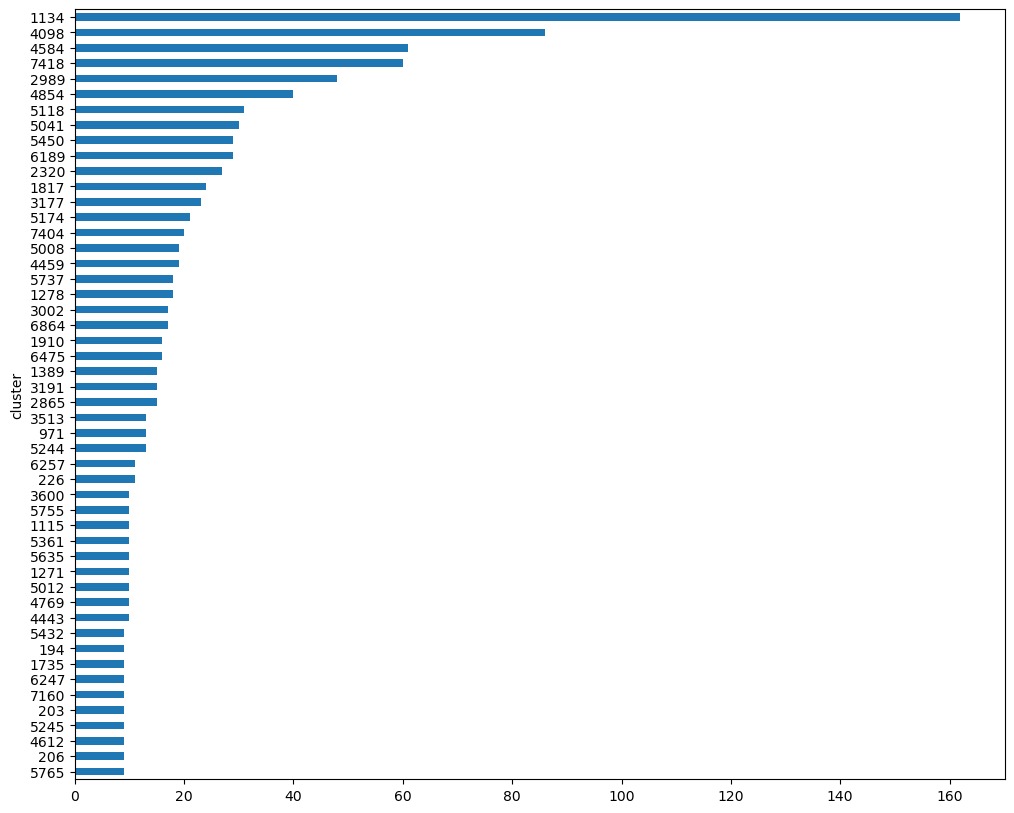

In [108]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [109]:
top_clusters = df['cluster'].value_counts().index.values
top_clusters

array([1134, 4098, 4584, ..., 3495, 3494, 5650], dtype=int64)

In [111]:
for cluster in top_clusters[0:100]:
    
    print('cluster: {}'.format(cluster))
    
    cluster_data = df[df['cluster']==cluster].head(20)['claim'].values
    print(cluster_data)
    
    print()

cluster: 1134
['URL likely leads to news article or update related to a specific event or topic.'
 'URL likely leads to news article or update related to a specific event or topic.'
 'URL likely leads to news article or update related to a specific event or topic.'
 'URL likely leads to news article or update related to a specific event or topic.'
 'A news update related to a specific article.'
 'A news update related to a specific article.'
 'A news update related to a specific article.'
 'News article or announcement regarding a specific event or topic.'
 'News article related to a specific event or topic'
 'News article related to a specific event or topic'
 'News article related to a specific event or topic'
 'News article related to a specific event or topic'
 'News article about an event or situation in Andalusia'
 'Claim regarding a specific event or news story.'
 'Video content related to an event in Madrid'
 'Local news article covering a specific event or issue in the communi

In [112]:
# top trends / top stories

# US Border Patrol Chief Michael Banks has resigned
# US Supreme Court is doing something in relation to the abortion pill mifepristone. Reproductive health.
# Long Island Rail Road Strike
# Dylan Sprouse and Barbara Palvin will have a child; Barbara is pregnant
# Explosion at a lumber mill in maine
# Red states pressuring social service workers to participate in immigration enforcement
# US Supreme Court has ruled that telehealth abortions can resume while lawsuit is in process
# US Supreme Court preserves access to abortion pill during lawsuit
# Oregon Governor Kotek signs laws to support Planned Parenthood funding and protect health rights
# Potential for a Long Island Rail Road Strike if deal not reached
# US Supreme Court allows abortion pill to remain available by mail across the country
# Man in critical condition after shark attack at Rottnest Island in Perth, Australia
# CBS cameraman has medical emergency during live broadcast
# Hospital opens first detransition clinic as part of a settlement with DOJ
# Woman sentenced to life in prison for murdering husband
# Tourist arrested for throwing rock at endangered seal in Hawaii
# Police officer shot high school student who was playing with water gun during senior game
# More than 40 people being monitored across the US for hantavirus

# Ok, that is enough to show that World AI and clustering is powerful together. Let's move past easy stuff.

# Keyword Analysis

It's funny, I'm calling my above clustering analysis as easy stuff, but that's because I built a useful clustering algorithm for myself that has made everything easy. The really easy stuff is keyword analysis. To do that, take text and extract the tokens, bigrams, and trigrams. Then count them.

This is really rudamentary and will be a different kind of lens, not a replacement for clustering.

It is useful to know different kinds of tools. Clustering is useful and so is keyword analysis. :)

In [113]:
text = " ".join(df['claim'])

text[0:1000]

'URL likely leads to news article or update related to a specific event or topic. URL likely leads to news article or update related to a specific event or topic. URL likely leads to news article or update related to a specific event or topic. URL likely leads to news article or update related to a specific event or topic. UP Police arrests a university professor for alleged misconduct and paper leak Event for speed dating targeting individuals aged 50-65 Community nonprofits are collaborating to rejuvenate West Valley Park. Event details for an upcoming gathering at Busboys and Poets Event related to the Return to Self community Severe thunderstorm warnings have been lifted in Omaha metro, but the threat of storms continues. San Jose is cutting funding for immigrant defense due to budget issues. Ashleigh Flynn and the Riveters are performing at McMenamins Hotel Oregon. Barrie Dempsey is performing at 19 Acres Cider. There is a free event called Flowstice - Le Cycle du Soleil in Montre

In [114]:
len(text)

656609

## Token Counts

A few years ago, few people talked about tokens. Now, everybody talks about tokens. The internet is multilingual, but if you are dealing with the English language, tokens are singular things (words, numbers, etc).

In [115]:
text.split()[0:20] # that is twenty tokens

['URL',
 'likely',
 'leads',
 'to',
 'news',
 'article',
 'or',
 'update',
 'related',
 'to',
 'a',
 'specific',
 'event',
 'or',
 'topic.',
 'URL',
 'likely',
 'leads',
 'to',
 'news']

If you split on space on Chinese or Japanese problems, you will not get tokens. Nothing will be split. 

In [116]:
zh_text = '我爱你'

ja_text = '愛してます'

In [117]:
zh_text.split()

['我爱你']

In [118]:
ja_text.split()

['愛してます']

So, with certain languages, you have to use different tokenization processes. I wonder if modern AI engineers still learn this.

In [119]:
list(zh_text)

['我', '爱', '你']

In [120]:
list(ja_text)

['愛', 'し', 'て', 'ま', 'す']

That's actually so funny to me that that works... Could have totally overengineered that split. Hahaha...

But today, I'm going to just use space tokenization and capture tokens, bigrams, and trigrams.

Token = 1 thing

Bigram = 2 tokens

Trigram = 3 tokens


I

I love

I love you




But before moving on, let's just get the top token counts.

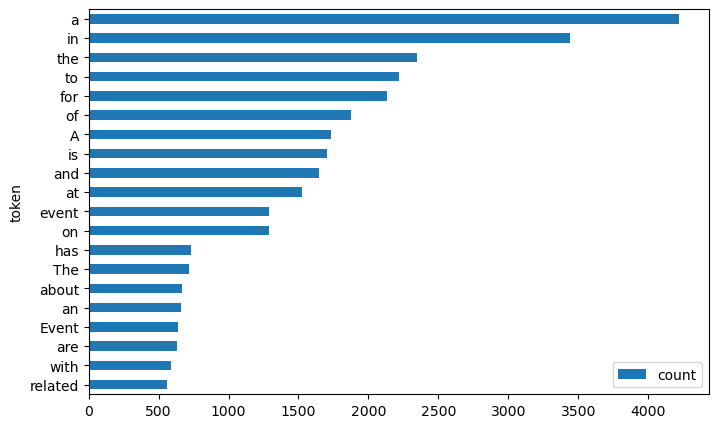

In [121]:
tokens = text.split()

# stop_words = set(stopwords.words('english'))
# tokens = [t for t in tokens if t.lower() not in stop_words]

counts = Counter(tokens)

token_counts = counts.most_common(20)

check_df = pd.DataFrame(token_counts, columns=['token', 'count'])
check_df.set_index('token')[0:20].plot.barh(figsize=(8,5)).invert_yaxis()

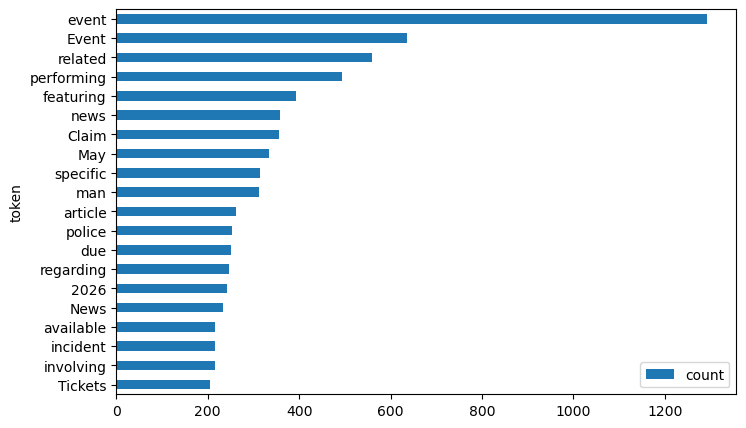

In [122]:
tokens = text.split()

stop_words = set(stopwords.words('english'))
tokens = [t for t in tokens if t.lower() not in stop_words]

counts = Counter(tokens)

token_counts = counts.most_common(20)

check_df = pd.DataFrame(token_counts, columns=['token', 'count'])
check_df.set_index('token')[0:20].plot.barh(figsize=(8,5)).invert_yaxis()

Excellent. This shows the importance of thinking about stopwords when you are doing anything with Natural Language Processing. If you are doing anything with Artificial Intelligence, you are doing things with Natural Language Processing. You either have these fundamentals or you do not.

# Tokens, Bigrams, and Trigrams

A token is one thing, a bigram is two tokens, and a trigram is three tokens.

In [123]:
tokens = text.split()

stop_words = set(stopwords.words('english'))
tokens = [t for t in tokens if t.lower() not in stop_words]

tokens[0:50]

['URL',
 'likely',
 'leads',
 'news',
 'article',
 'update',
 'related',
 'specific',
 'event',
 'topic.',
 'URL',
 'likely',
 'leads',
 'news',
 'article',
 'update',
 'related',
 'specific',
 'event',
 'topic.',
 'URL',
 'likely',
 'leads',
 'news',
 'article',
 'update',
 'related',
 'specific',
 'event',
 'topic.',
 'URL',
 'likely',
 'leads',
 'news',
 'article',
 'update',
 'related',
 'specific',
 'event',
 'topic.',
 'Police',
 'arrests',
 'university',
 'professor',
 'alleged',
 'misconduct',
 'paper',
 'leak',
 'Event',
 'speed']

In [124]:
from nltk.util import ngrams

bigrams = list(ngrams(tokens, 2))
bigrams = [" ".join(tokens) for tokens in bigrams]

bigrams[0:50]

['URL likely',
 'likely leads',
 'leads news',
 'news article',
 'article update',
 'update related',
 'related specific',
 'specific event',
 'event topic.',
 'topic. URL',
 'URL likely',
 'likely leads',
 'leads news',
 'news article',
 'article update',
 'update related',
 'related specific',
 'specific event',
 'event topic.',
 'topic. URL',
 'URL likely',
 'likely leads',
 'leads news',
 'news article',
 'article update',
 'update related',
 'related specific',
 'specific event',
 'event topic.',
 'topic. URL',
 'URL likely',
 'likely leads',
 'leads news',
 'news article',
 'article update',
 'update related',
 'related specific',
 'specific event',
 'event topic.',
 'topic. Police',
 'Police arrests',
 'arrests university',
 'university professor',
 'professor alleged',
 'alleged misconduct',
 'misconduct paper',
 'paper leak',
 'leak Event',
 'Event speed',
 'speed dating']

In [125]:
trigrams = list(ngrams(tokens, 3))
trigrams = [" ".join(tokens) for tokens in trigrams]

trigrams[0:50]

['URL likely leads',
 'likely leads news',
 'leads news article',
 'news article update',
 'article update related',
 'update related specific',
 'related specific event',
 'specific event topic.',
 'event topic. URL',
 'topic. URL likely',
 'URL likely leads',
 'likely leads news',
 'leads news article',
 'news article update',
 'article update related',
 'update related specific',
 'related specific event',
 'specific event topic.',
 'event topic. URL',
 'topic. URL likely',
 'URL likely leads',
 'likely leads news',
 'leads news article',
 'news article update',
 'article update related',
 'update related specific',
 'related specific event',
 'specific event topic.',
 'event topic. URL',
 'topic. URL likely',
 'URL likely leads',
 'likely leads news',
 'leads news article',
 'news article update',
 'article update related',
 'update related specific',
 'related specific event',
 'specific event topic.',
 'event topic. Police',
 'topic. Police arrests',
 'Police arrests university',

# Capture Counts

Before we attempt trend analysis, let's first be able to capture useful trends. I don't want to know that the word the was use 20,000 times this week. That's why we removed stop words. We should have somewhat decent tokens to count, now.

With bigrams and trigrams, we do not remove stop words, else they would become confusing. "Jack and Jill" would become "Jack Jill".

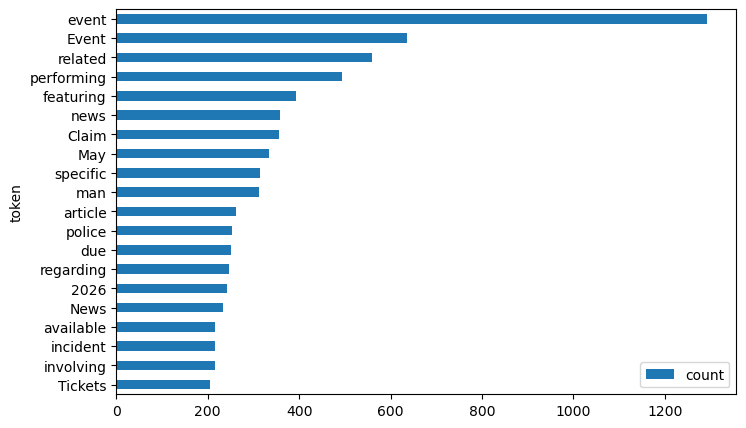

In [126]:
counts = Counter(tokens)

token_counts = counts.most_common(20)

check_df = pd.DataFrame(token_counts, columns=['token', 'count'])
check_df.set_index('token')[0:20].plot.barh(figsize=(8,5)).invert_yaxis()

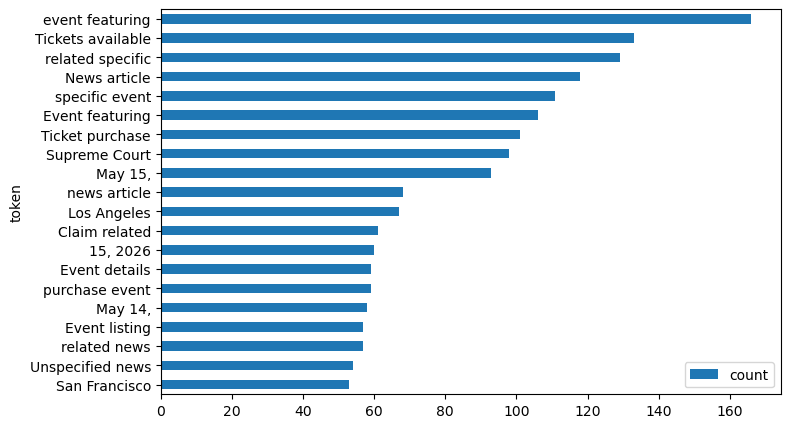

In [127]:
counts = Counter(bigrams)

token_counts = counts.most_common(20)

check_df = pd.DataFrame(token_counts, columns=['token', 'count'])
check_df.set_index('token')[0:20].plot.barh(figsize=(8,5)).invert_yaxis()

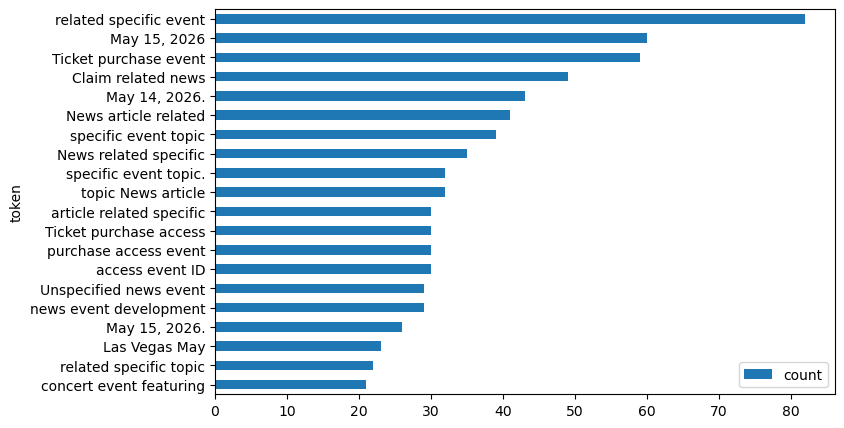

In [128]:
counts = Counter(trigrams)

token_counts = counts.most_common(20)

check_df = pd.DataFrame(token_counts, columns=['token', 'count'])
check_df.set_index('token')[0:20].plot.barh(figsize=(8,5)).invert_yaxis()

# Let's Do Stuff For Real

That approach isn't great for use, because I put all of the text into a text variable to make this explanation easier. Instead of doing that, we need to extract the tokens, bigrams, and trigrams from each record, not smash all records together.

Heh... trend_master_df. That sounds like a DJ name or something. lol

In [198]:
trend_master_df = df[['date_added', 'claim']].copy()

trend_master_df['tokens'] = trend_master_df['claim'].apply(lambda s: s.split())
trend_master_df['bigrams'] = trend_master_df['claim'].apply(lambda s: [" ".join(tokens) for tokens in ngrams(s.split(), 2)])
trend_master_df['trigrams'] = trend_master_df['claim'].apply(lambda s: [" ".join(tokens) for tokens in ngrams(s.split(), 3)])

trend_master_df.head()

,date_added,claim,tokens,bigrams,trigrams
0,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n..."
3,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n..."
1,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n..."
2,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n..."
4,2026-05-15 22:43:35-07:00,UP Police arrests a university professor for a...,"[UP, Police, arrests, a, university, professor...","[UP Police, Police arrests, arrests a, a unive...","[UP Police arrests, Police arrests a, arrests ..."


In [199]:
trend_master_df['tokens']

0       [URL, likely, leads, to, news, article, or, up...
3       [URL, likely, leads, to, news, article, or, up...
1       [URL, likely, leads, to, news, article, or, up...
2       [URL, likely, leads, to, news, article, or, up...
4       [UP, Police, arrests, a, university, professor...
                              ...                        
9995    [The, Oregon, State, Fair, is, adding, more, a...
9996    [Celebration, of, life, photos, for, the, foun...
9997    [Two, juveniles, were, injured, in, a, shootin...
9998    [A, heroic, police, officer, saved, a, Tenness...
9999    [An, escalator, malfunction, at, Broadway's, G...
Name: tokens, Length: 10000, dtype: object

In [200]:
trend_master_df['bigrams']

0       [URL likely, likely leads, leads to, to news, ...
3       [URL likely, likely leads, leads to, to news, ...
1       [URL likely, likely leads, leads to, to news, ...
2       [URL likely, likely leads, leads to, to news, ...
4       [UP Police, Police arrests, arrests a, a unive...
                              ...                        
9995    [The Oregon, Oregon State, State Fair, Fair is...
9996    [Celebration of, of life, life photos, photos ...
9997    [Two juveniles, juveniles were, were injured, ...
9998    [A heroic, heroic police, police officer, offi...
9999    [An escalator, escalator malfunction, malfunct...
Name: bigrams, Length: 10000, dtype: object

In [201]:
trend_master_df['trigrams']

0       [URL likely leads, likely leads to, leads to n...
3       [URL likely leads, likely leads to, leads to n...
1       [URL likely leads, likely leads to, leads to n...
2       [URL likely leads, likely leads to, leads to n...
4       [UP Police arrests, Police arrests a, arrests ...
                              ...                        
9995    [The Oregon State, Oregon State Fair, State Fa...
9996    [Celebration of life, of life photos, life pho...
9997    [Two juveniles were, juveniles were injured, w...
9998    [A heroic police, heroic police officer, polic...
9999    [An escalator malfunction, escalator malfuncti...
Name: trigrams, Length: 10000, dtype: object

Bigrams and Trigrams are going to be tricky to work with for trend analysis without additional filtering, so let's stick to tokens for today. I will just show the bigram and trigram counts so that you can see.

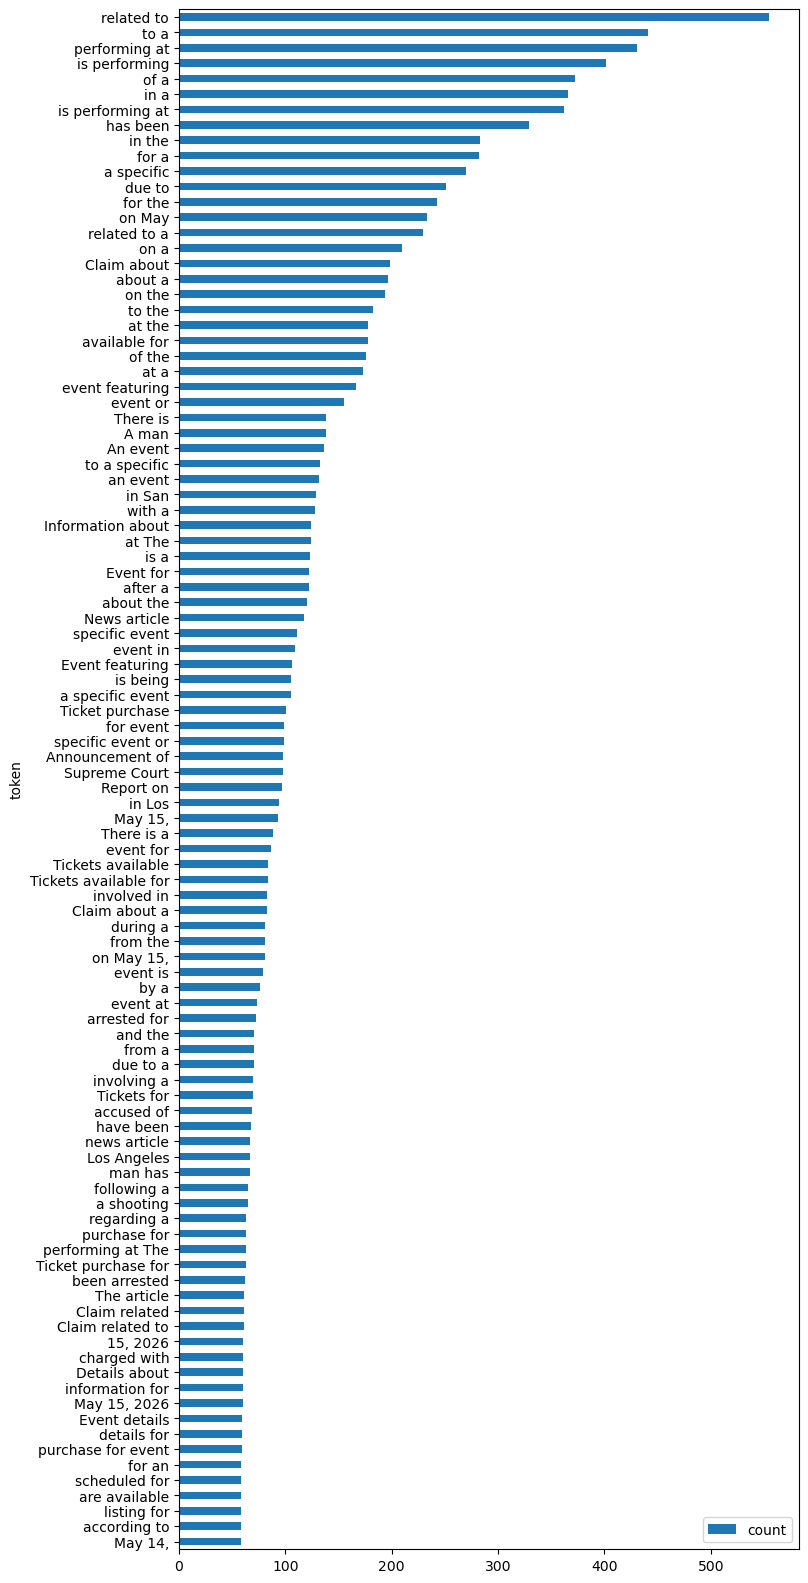

In [202]:
phrase_list = list(trend_master_df['bigrams'].explode()) + list(trend_master_df['trigrams'].explode())

counts = Counter(phrase_list)

token_counts = counts.most_common(100)

check_df = pd.DataFrame(token_counts, columns=['token', 'count'])
check_df.set_index('token').plot.barh(figsize=(8,20)).invert_yaxis()

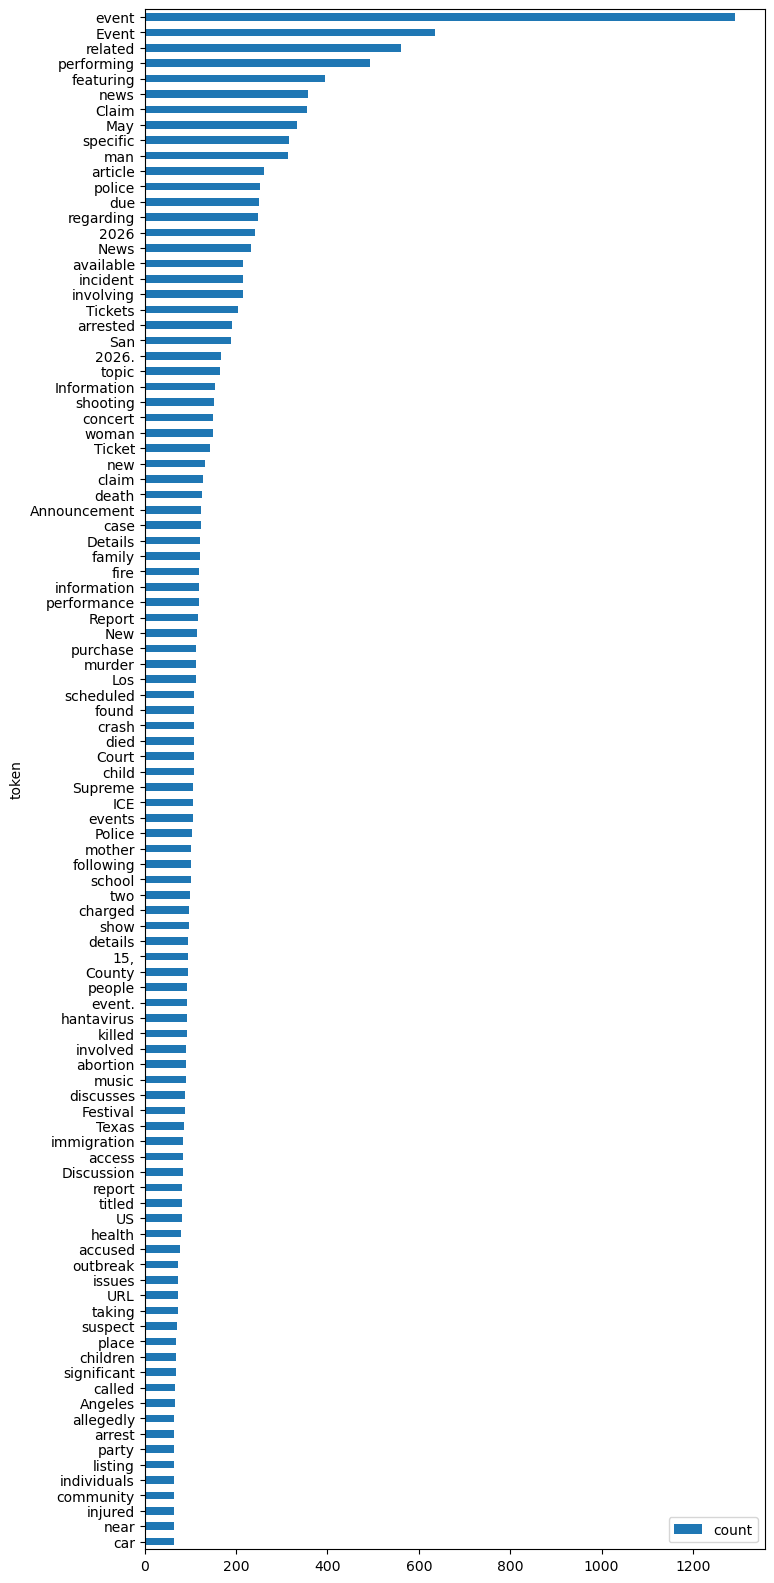

In [203]:
# if want to lowercase everything; but information is lost. ICE becomes ice which is less noticeable and like water

tokens = [token for sublist in trend_master_df['tokens'] for token in sublist]
stop_words = set(stopwords.words('english'))
tokens = [t for t in tokens if t.lower() not in stop_words]

#tokens = [t.lower() for t in tokens]

counts = Counter(tokens)

token_counts = counts.most_common(100)

check_df = pd.DataFrame(token_counts, columns=['token', 'count'])
check_df.set_index('token').plot.barh(figsize=(8,20)).invert_yaxis()

# We're Getting Closer

It's not trend analysis if you aren't factoring in time. It's just a count of words right now.

In [204]:
trend_master_df

,date_added,claim,tokens,bigrams,trigrams
0,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n..."
3,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n..."
1,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n..."
2,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n..."
4,2026-05-15 22:43:35-07:00,UP Police arrests a university professor for a...,"[UP, Police, arrests, a, university, professor...","[UP Police, Police arrests, arrests a, a unive...","[UP Police arrests, Police arrests a, arrests ..."
...,...,...,...,...,...
9995,2026-05-13 19:45:14-07:00,The Oregon State Fair is adding more artists t...,"[The, Oregon, State, Fair, is, adding, more, a...","[The Oregon, Oregon State, State Fair, Fair is...","[The Oregon State, Oregon State Fair, State Fa..."
9996,2026-05-13 19:45:14-07:00,Celebration of life photos for the founder of ...,"[Celebration, of, life, photos, for, the, foun...","[Celebration of, of life, life photos, photos ...","[Celebration of life, of life photos, life pho..."
9997,2026-05-13 19:44:32-07:00,Two juveniles were injured in a shooting in Ho...,"[Two, juveniles, were, injured, in, a, shootin...","[Two juveniles, juveniles were, were injured, ...","[Two juveniles were, juveniles were injured, w..."
9998,2026-05-13 19:41:56-07:00,A heroic police officer saved a Tennessee fami...,"[A, heroic, police, officer, saved, a, Tenness...","[A heroic, heroic police, police officer, offi...","[A heroic police, heroic police officer, polic..."


In [205]:
trend_master_df['date_added'] = pd.to_datetime(trend_master_df['date_added'])

trend_master_df['date_h'] = trend_master_df['date_added'].dt.strftime('%Y%m%d %H')

trend_master_df.head()

,date_added,claim,tokens,bigrams,trigrams,date_h
0,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n...",20260515 22
3,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n...",20260515 22
1,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n...",20260515 22
2,2026-05-15 22:46:56-07:00,URL likely leads to news article or update rel...,"[URL, likely, leads, to, news, article, or, up...","[URL likely, likely leads, leads to, to news, ...","[URL likely leads, likely leads to, leads to n...",20260515 22
4,2026-05-15 22:43:35-07:00,UP Police arrests a university professor for a...,"[UP, Police, arrests, a, university, professor...","[UP Police, Police arrests, arrests a, a unive...","[UP Police arrests, Police arrests a, arrests ...",20260515 22


In [207]:
trend_df = trend_master_df[['date_h', 'tokens']]
trend_df.explode('tokens')

,date_h,tokens
0,20260515 22,URL
0,20260515 22,likely
0,20260515 22,leads
0,20260515 22,to
0,20260515 22,news
...,...,...
9999,20260513 19,in
9999,20260513 19,injuries
9999,20260513 19,to
9999,20260513 19,9


In [219]:
trend_df = trend_master_df[['date_h', 'tokens']].explode('tokens')

trend_df = trend_df.groupby(['date_h', 'tokens']).size().reset_index(name='count')

trend_df = trend_df.sort_values(['date_h', 'count'], ascending=[False, False])
trend_df

,date_h,tokens,count
51839,20260515 22,event,52
51855,20260515 22,for,48
51714,20260515 22,a,40
51889,20260515 22,in,33
51901,20260515 22,is,32
...,...,...,...
341,20260513 19,workers,1
342,20260513 19,wrongful,1
343,20260513 19,years,1
344,20260513 19,years.,1


In [220]:
stop_words = set(stopwords.words('english'))

trend_df = trend_df[trend_df['tokens'].str.lower().isin(stop_words) == False]
trend_df

,date_h,tokens,count
51839,20260515 22,event,52
51685,20260515 22,Ticket,28
51992,20260515 22,purchase,28
51977,20260515 22,performing,17
51458,20260515 22,2026.,9
...,...,...,...
341,20260513 19,workers,1
342,20260513 19,wrongful,1
343,20260513 19,years,1
344,20260513 19,years.,1


In [223]:
for date_h, group in trend_df.groupby('date_h', sort=False):
    print(date_h)
    print()
    print(group.nlargest(20, 'count')[['tokens', 'count']].to_string(index=False))
    print()
    print()

20260515 22

    tokens  count
     event     52
    Ticket     28
  purchase     28
performing     17
     2026.      9
   related      9
       May      8
   article      7
 scheduled      7
       16,      6
    called      6
      2026      5
     Event      5
      news      5
  specific      5
       URL      4
     leads      4
    likely      4
    police      4
    taking      4


20260515 21

    tokens  count
performing     22
     event     12
       May     10
     2026.      8
       man      6
     shark      6
    strike      6
       16,      4
    attack      4
      died      4
       due      4
    family      4
  incident      4
   injured      4
 regarding      4
   related      4
    social      4
     (Main      3
       15,      3
      2026      3


20260515 20

     tokens  count
 performing     36
      Event     13
  featuring     13
       2026     11
        May     11
        16,     10
    related     10
    concert      8
      event      8
        ICE

      tokens  count
       event     31
       Event     18
         due     11
   featuring     11
         Los      8
         May      8
     article      7
         man      7
     related      7
        2026      6
     Angeles      6
     Dallas.      6
       Texas      6
announcement      6
    arrested      6
   involving      6
  hantavirus      5
    incident      5
       music      5
        news      5


20260514 06

    tokens  count
     event     34
     Claim     30
     Event     27
performing     18
   related     17
   article     16
 featuring     16
      News     13
  specific     12
     topic     10
       May      9
     claim      9
    police      9
   unknown      9
  arrested      8
     crash      7
 involving      7
       man      7
     2026.      6
    County      6


20260514 05

     tokens  count
      event     11
Information     10
      Event      9
    article      8
    Details      7
        May      7
       News      7
  featuring      7
 

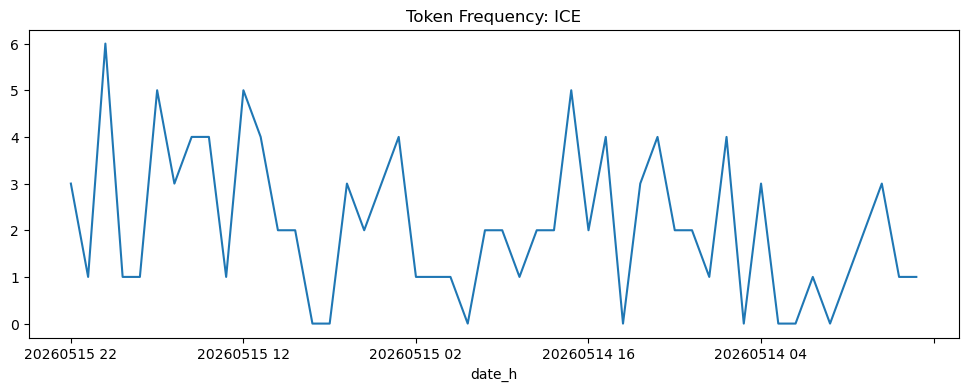

In [250]:
search_term = 'ICE'

check_df = trend_df[trend_df['tokens'] == search_term]
check_df = check_df.set_index('date_h')

full_index = pd.Index(sorted(trend_df['date_h'].unique(), reverse=True), name='date_h')
check_df = check_df.reindex(full_index, fill_value=0)

_= check_df['count'].plot.line(figsize=(12, 4), title='Token Frequency: {}'.format(search_term))

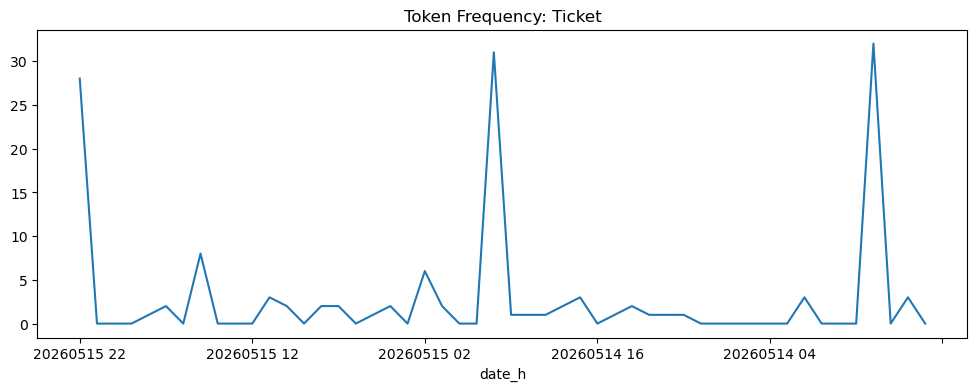

In [251]:
search_term = 'Ticket'

check_df = trend_df[trend_df['tokens'] == search_term]
check_df = check_df.set_index('date_h')

full_index = pd.Index(sorted(trend_df['date_h'].unique(), reverse=True), name='date_h')
check_df = check_df.reindex(full_index, fill_value=0)

_= check_df['count'].plot.line(figsize=(12, 4), title='Token Frequency: {}'.format(search_term))

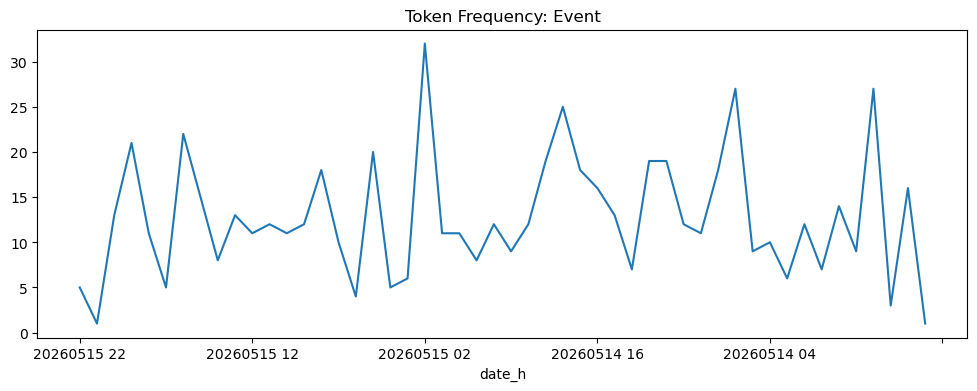

In [252]:
search_term = 'Event'

check_df = trend_df[trend_df['tokens'] == search_term]
check_df = check_df.set_index('date_h')

full_index = pd.Index(sorted(trend_df['date_h'].unique(), reverse=True), name='date_h')
check_df = check_df.reindex(full_index, fill_value=0)

_= check_df['count'].plot.line(figsize=(12, 4), title='Token Frequency: {}'.format(search_term))